# Question 4: Production optimization

Weekly production and inventory planning over $T=52$ weeks for $n=20$ products made from $m=500$ materials. 

In [1]:
using CSV, DataFrames, JuMP, Gurobi, Plots, Printf
gr(); default(left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)

## Data

In [2]:
datadir = joinpath(@__DIR__, "HW1_data")
readmat(f) = Matrix{Float64}(CSV.read(joinpath(datadir, f), DataFrame)[:, 2:end])  

A = readmat("requirements.csv")                              
b = readmat("availability.csv")                              
d = readmat("demand.csv")                                    
p = CSV.read(joinpath(datadir, "profit.csv"),  DataFrame).profit   
h = CSV.read(joinpath(datadir, "holding.csv"), DataFrame).holding  

m, n = size(A)
T = size(d, 2)
@assert size(b) == (m, T) && length(p) == n && length(h) == T
(m = m, n = n, T = T)

(m = 500, n = 20, T = 52)

## (a) Formulation

We have Products $i = 1,\dots,n$ ($n=20$); materials $j = 1,\dots,m$ ($m=500$); weeks $t = 1,\dots,T$ ($T=52$).



### **We have the following data:**


$a_{ji}$: how much of material $j$ one unit of product $i$ needs (from requirements.csv)

$b_{jt}$: how much of material $j$ is available in week $t$ (from availability.csv)

$d_{it}$: the demand for product $i$ in week $t$ (from demand.csv)

$p_i$ is the unit profit of product $i$ (from profit.csv)

$h_t$ is the unit holding cost for inventory at the end of week $t$ (from holding.csv).



We can either sell, make, or hold inventory of each product in each week. The goal is to maximize profit over the planning horizon (minus inventory holding costs). 
### **Decision variables & Model**
- $x_{it} \ge 0$: units of product $i$ made in week $t$
- $s_{it} \ge 0$: units of product $i$ sold in week $t$
- $I_{it} \ge 0$: units of product $i$ in inventory at the end of week $t$, with $I_{i0} = 0$ (no starting stock)



$$
\begin{aligned}
\max_{x,s,I}\quad & \sum_{i=1}^{n}\sum_{t=1}^{T} p_i\, s_{it} \;-\; \sum_{i=1}^{n}\sum_{t=1}^{T} h_t\, I_{it} \\
\text{s.t.}\quad
& \sum_{i=1}^{n} a_{ji}\, x_{it} \le b_{jt} && \forall j,\ t && \text{(weekly material availability, no carry-over)}\\
& s_{it} \le d_{it} && \forall i,\ t && \text{(cannot sell more than demand)}\\
& I_{i,t-1} + x_{it} - s_{it} = I_{it} && \forall i,\ t && \text{(inventory balance, } I_{i0}=0\text{)}\\
& x_{it},\ s_{it},\ I_{it} \ge 0 && \forall i,\ t
\end{aligned}
$$

## (b) Implementation

In [3]:
model = Model(Gurobi.Optimizer)
set_silent(model)

@variable(model, x[1:n, 1:T] >= 0)   # production
@variable(model, s[1:n, 1:T] >= 0)   # sales
@variable(model, I[1:n, 1:T] >= 0)   # end-of-week inventory

@constraint(model, material[j = 1:m, t = 1:T], sum(A[j, i] * x[i, t] for i in 1:n) <= b[j, t])
@constraint(model, demand[i = 1:n, t = 1:T], s[i, t] <= d[i, t])
@constraint(model, balance[i = 1:n, t = 1:T], (t == 1 ? 0.0 : I[i, t-1]) + x[i, t] - s[i, t] == I[i, t])

@expression(model, sales_profit, sum(p[i] * s[i, t] for i in 1:n, t in 1:T))
@expression(model, holding_cost, sum(h[t] * I[i, t] for i in 1:n, t in 1:T))
@objective(model, Max, sales_profit - holding_cost)

optimize!(model)
@assert termination_status(model) == MOI.OPTIMAL
termination_status(model)

Set parameter Username
Set parameter LicenseID to value 2857457
Academic license - for non-commercial use only - expires 2027-08-26


OPTIMAL::TerminationStatusCode = 1

In [4]:
X, S, Inv = value.(x), value.(s), value.(I)
tol = 1e-6

@printf("Sales profit : \$%12.2f\n", value(sales_profit))
@printf("Holding cost : \$%12.2f\n", value(holding_cost))
@printf("Net profit   : \$%12.2f\n", objective_value(model))
println()
@printf("Units sold: %.1f of %.1f demanded (%.1f%%)\n", sum(S), sum(d), 100 * sum(S) / sum(d))

Sales profit : $  1370384.72
Holding cost : $     7371.37
Net profit   : $  1363013.36

Units sold: 15807.4 of 246100.3 demanded (6.4%)


**Result.** The optimal solution yields a sales profit of **$1,370,384.72** and a holding cost of **$7,371.37**, corresponding to a net profit of **$1,363,013.36**.

## (c) Graphical analysis

### (i) Units manufactured per product and week

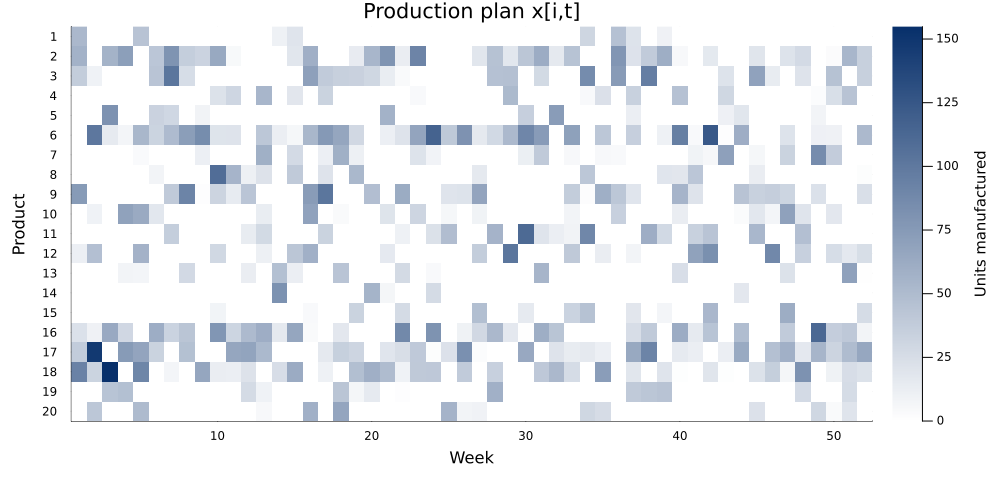

In [5]:
seq = cgrad([:white, "#08306b"])    # single-hue sequential: white = 0
heatmap(1:T, 1:n, X;
    c = seq, clims = (0, maximum(X)),
    xlabel = "Week", ylabel = "Product", yticks = 1:n, yflip = true,
    colorbar_title = "Units manufactured",
    title = "Production plan x[i,t]", size = (1000, 480))

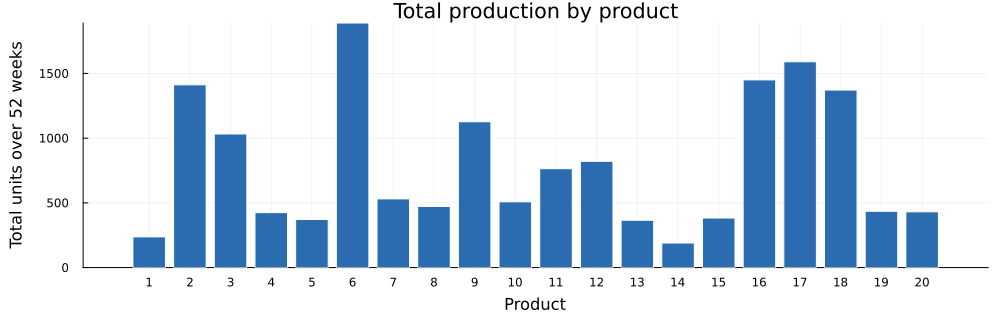

In [6]:
bar(1:n, vec(sum(X, dims = 2)); color = "#2b6cb0", linecolor = :white, legend = false,
    xlabel = "Product", ylabel = "Total units over 52 weeks", xticks = 1:n,
    title = "Total production by product", size = (1000, 320))

**Interpretation.** Production is relatively **sparse** and uneven across products and weeks. In most weeks, only a subset of the 20 products is manufactured, and the set of products produced changes substantially over time. Products 6, 16, 17, 18, 2, and 9 account for particularly large amounts of total production, while several other products are produced much less frequently. This variation occurs because material availability changes each week, so the optimal production plan changes accordingly.

### (ii) Number of product types manufactured each week

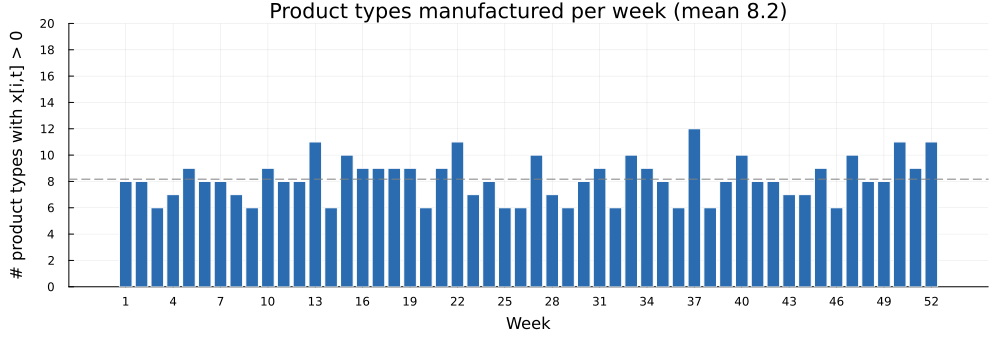

In [7]:
nprod     = [count(>(tol), X[:, t]) for t in 1:T]
nmat_bind = [count(A * X[:, t] .>= b[:, t] .- tol) for t in 1:T]
ndem_bind = [count(S[:, t] .>= d[:, t] .- tol) for t in 1:T]

bar(1:T, nprod; color = "#2b6cb0", linecolor = :white, legend = false,
    xlabel = "Week", ylabel = "# product types with x[i,t] > 0",
    ylims = (0, n), yticks = 0:2:n, xticks = 1:3:T,
    title = "Product types manufactured per week (mean $(round(sum(nprod)/T, digits=1)))",
    size = (1000, 340))
hline!([sum(nprod) / T]; color = :gray, linestyle = :dash)

In [8]:
println("Weeks where #products made == #binding materials: $(count(nprod .== nmat_bind)) / $T")
println("Every week, #made ≤ #binding materials + #demands met: $(all(nprod .<= nmat_bind .+ ndem_bind))")
DataFrame(week = 1:T, products_made = nprod, materials_binding = nmat_bind, demands_met = ndem_bind)

Weeks where #products made == #binding materials: 47 / 52
Every week, #made ≤ #binding materials + #demands met: true


Row,week,products_made,materials_binding,demands_met
,Int64,Int64,Int64,Int64
1,1,8,8,0
2,2,8,8,0
3,3,6,6,0
4,4,7,7,1
5,5,9,8,2
6,6,8,8,0
7,7,8,8,0
8,8,7,7,0
9,9,6,6,1


**Interpretation.** Between 6 and 12 of the 20 product types are manufactured each week, with an average of 8.2. Thus, the optimal solution generally concentrates production on only a subset of products rather than producing all 20 each week. 

The number of products manufactured equals the number of binding material constraints in 47 of the 52 weeks. In the remaining weeks, binding demand constraints also play a role. This suggests that weekly production is largely determined by a small set of scarce materials, and the relevant bottlenecks changes from week to week.

### (iii) Units in inventory per product and week

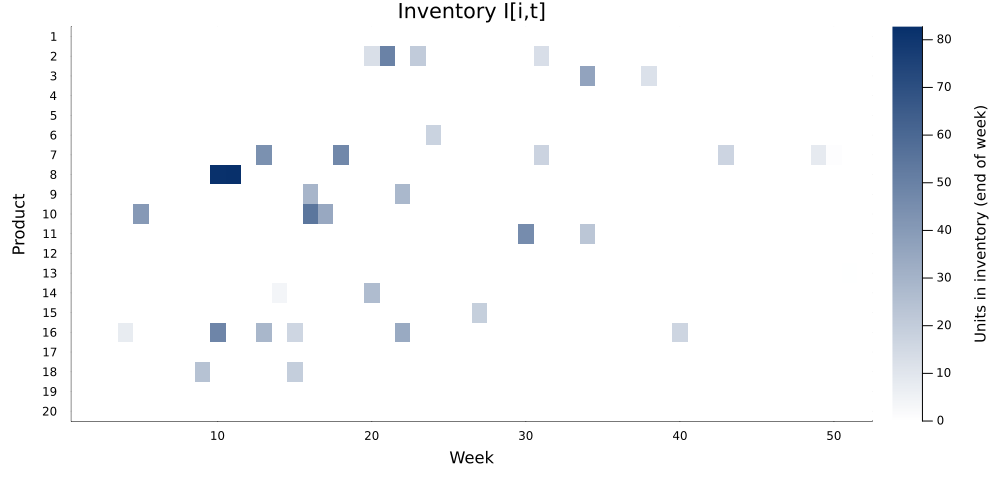

In [9]:
heatmap(1:T, 1:n, Inv;
    c = seq, clims = (0, maximum(Inv)),
    xlabel = "Week", ylabel = "Product", yticks = 1:n, yflip = true,
    colorbar_title = "Units in inventory (end of week)",
    title = "Inventory I[i,t]", size = (1000, 480))

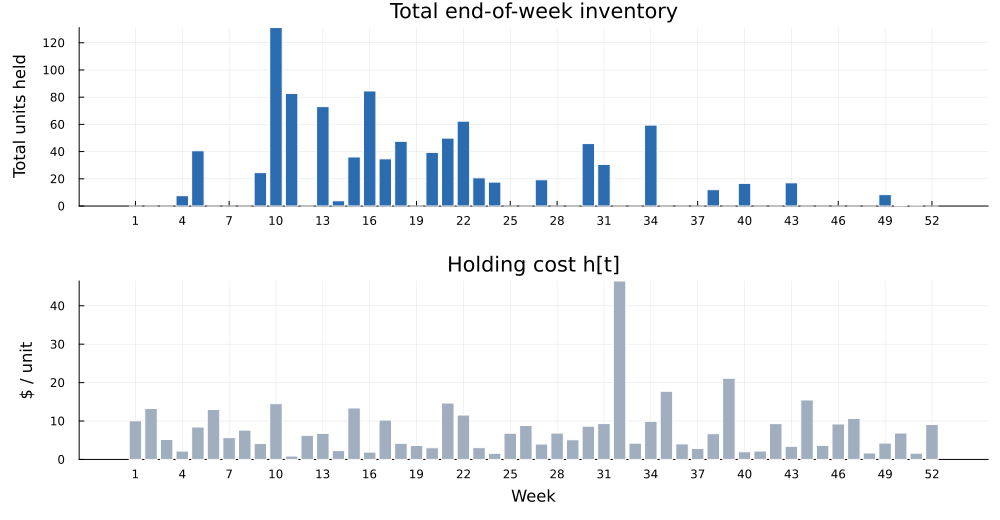

In [10]:
p1 = bar(1:T, vec(sum(Inv, dims = 1)); color = "#2b6cb0", linecolor = :white, legend = false,
         ylabel = "Total units held", title = "Total end-of-week inventory", xticks = 1:3:T)
p2 = bar(1:T, h; color = "#a0aec0", linecolor = :white, legend = false,
         xlabel = "Week", ylabel = "\$ / unit", title = "Holding cost h[t]", xticks = 1:3:T)
plot(p1, p2; layout = (2, 1), size = (1000, 520), link = :x)

In [11]:
held = [(i, t) for i in 1:n, t in 1:T if Inv[i, t] > tol]
prebuilt_unsaturated = [(i, t) for i in 1:n, t in 1:T if X[i, t] > tol && Inv[i, t] > tol && S[i, t] < d[i, t] - tol]
multiweek = [(i, t) for i in 1:n, t in 2:T if Inv[i, t] > tol && Inv[i, t-1] > tol]
top5 = sortperm(h, rev = true)[1:5]
println("(product, week) cells with positive inventory: $(length(held)) of $(n * T)")
println("Stock built while that week's demand was NOT fully met: $(length(prebuilt_unsaturated))")
println("Units held for 2+ consecutive weeks (product, week): $multiweek")
println("Inventory at end of horizon: $(sum(Inv[:, T]))")
println("Total inventory in the 5 most expensive holding weeks $top5: $(round.(vec(sum(Inv, dims = 1))[top5], digits = 1))")

(product, week) cells with positive inventory: 34 of 1040
Stock built while that week's demand was NOT fully met: 0
Units held for 2+ consecutive weeks (product, week): [(8, 11), (10, 17), (2, 21), (7, 50)]
Inventory at end of horizon: 0.0
Total inventory in the 5 most expensive holding weeks [32, 39, 35, 44, 21]: [0.0, 0.0, 0.0, 0.0, 49.9]


**Interpretation.** Inventory is relatively sparse: **only 34 of the 1,040 product-week combinations have positive inventory**, and inventory is generally held for only a short period. 

This suggests that the model primarily produces goods when they are needed rather than storing them for long periods, since holding inventory incurs an additional cost. Inventory is used occasionally to shift production across weeks. For example, producing extra units in a week when materials are available and carrying them into a later week when production is more constrained. We also see that no inventory remains at the end of week 52.

## (d) Week 30

In [12]:
t0 = 30

use = A * X[:, t0]

full_mat = findall(use .>= b[:, t0] .- tol)
met_dem  = findall(S[:, t0] .>= d[:, t0] .- tol)

println("Materials fully utilized: ", length(full_mat), " of 500")
println("Materials: ", full_mat)

println("Products with demand fully met: ", length(met_dem), " of 20")
println("Products: ", met_dem)

Materials fully utilized: 8 of 500
Materials: [16, 42, 48, 141, 190, 201, 354, 484]
Products with demand fully met: 1 of 20
Products: [11]


**Answer.** In week 30, **8 of the 500 materials are fully utilized** (materials 16, 42, 48, 141, 190, 201, 354, and 484), while demand is fully satisfied for only **1 of the 20 products** (product 11). 

This means that 8 material availability constraints are binding, compared with only one demand constraint. Overall, production in week 30 is mainly limited by material availability rather than demand. Most products still have unmet demand, but producing more of them would require materials that are already fully utilized.
